In [ ]:
import random
import numpy as np

from datasets import load_from_disk


# Reproducibility
random.seed(42)
np.random.seed(42)

# Paths
GZ_RINGS_PATH = 'data/gz_rings_regression'
GZ_EUCLID_PATH = 'data/gz_euclid_default'

gz_rings = load_from_disk(GZ_RINGS_PATH)
gz_euclid = load_from_disk(GZ_EUCLID_PATH)

In [ ]:
from galaxy_dataset import load_rings_dataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
import torch

device = torch.device('mps')
img_size = 224

mean = (0.1153, 0.1078, 0.1053)
std  = (0.1106, 0.1041, 0.1001)

test_transform = T.Compose([T.Resize((img_size, img_size)),
                            T.ToDtype(torch.float32, scale=True),
                            T.Normalize(mean=mean, std=std)])

train_transform = T.Compose([T.Resize((img_size, img_size), antialias=True),
                             T.ToDtype(torch.float32, scale=True),
                             T.RandomVerticalFlip(0.5),
                             T.RandomHorizontalFlip(0.5),
                             T.RandomApply([T.ColorJitter(brightness=0.15,
                                                           contrast=0.15,
                                                             saturation=0.05, 
                                                             hue=0.02)], p=0.3),
                             T.Normalize(mean=mean, std=std)])

ring_sets = load_rings_dataset(data_path=GZ_RINGS_PATH,
                               train_transform=train_transform,
                               val_transform = test_transform,
                               test_transform = test_transform,
                               val_frac=0.2,random_state=42,
                               stratify=True,n_bins=10)

train_loader = DataLoader(ring_sets['train'], batch_size=32,
                           shuffle=True, num_workers=2)
val_loader   = DataLoader(ring_sets['val'], batch_size=32,
                           shuffle=False, num_workers=2)
test_loader  = DataLoader(ring_sets['test'], batch_size=32,
                           shuffle=False, num_workers=2)

In [3]:

from galaxy2vec import Galaxy2VecRegressor
model = Galaxy2VecRegressor(
    in_channels=3,
    feature_dim=256,
    hidden_dim=128,
    dropout=0.2,
).to(device)

batch = next(iter(train_loader))
x = batch['image'].to(device)

with torch.no_grad():
    yhat = model(x)

print('x shape:', x.shape)
print('x dtype:', x.dtype)
print('yhat shape:', yhat.shape)
print('yhat range:', yhat.min().item(), yhat.max().item())
print(batch['image'].shape, batch['image'].dtype)
print(batch['label'].shape, batch['label'].dtype)
print(batch['label'].min().item(), batch['label'].max().item())

x shape: torch.Size([32, 3, 224, 224])
x dtype: torch.float32
yhat shape: torch.Size([32, 1])
yhat range: 0.47589004039764404 0.5433116555213928
torch.Size([32, 3, 224, 224]) torch.float32
torch.Size([32]) torch.float32
0.0 1.0


In [ ]:
import torch.nn as nn
import torch.optim as optim
from train import Trainer

optimizer = optim.AdamW(model.parameters(), lr=1e-3,
                         weight_decay = 0.01 )
loss_fn = nn.MSELoss()


trainer = Trainer(model=model, optimizer=optimizer,
                   loss_fn=loss_fn, device=device)
history = trainer.fit(train_loader, val_loader, 
                      epochs=10)


Epoch 1/10


Training:   0%|          | 0/1834 [00:02<?, ?it/s]

Train | Loss: 0.0479 | MAE: 0.1781 | MSE: 0.0479 | RMSE: 0.2189


Val:   0%|          | 0/459 [00:13<?, ?it/s]

Val   | Loss: 0.0932 | MAE: 0.2498 | MSE: 0.0932 | RMSE: 0.3053

Epoch 2/10


...

Val   | Loss: 0.0312 | MAE: 0.1415 | MSE: 0.0312 | RMSE: 0.1765

Epoch 10/10


Training:   0%|          | 0/1834 [00:02<?, ?it/s]

Train | Loss: 0.0326 | MAE: 0.1446 | MSE: 0.0326 | RMSE: 0.1807


Val:   0%|          | 0/459 [00:02<?, ?it/s]

Val   | Loss: 0.0330 | MAE: 0.1447 | MSE: 0.0330 | RMSE: 0.1816


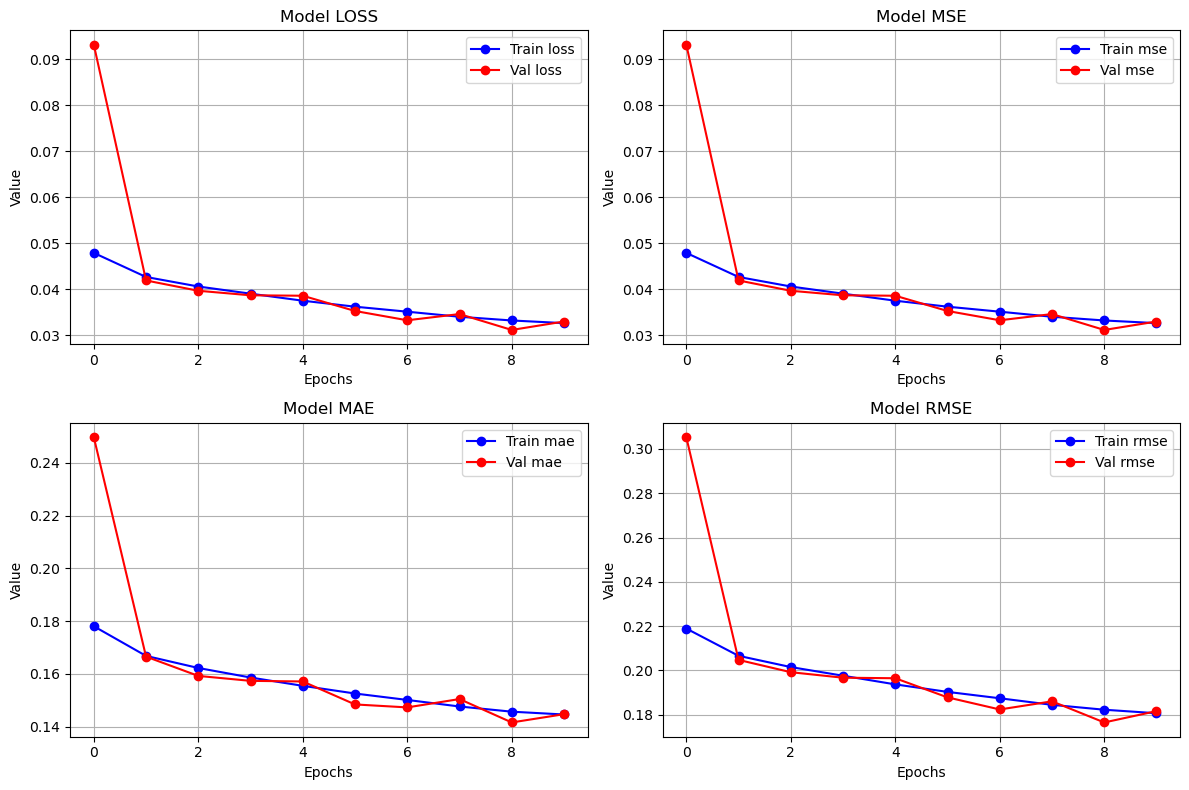

In [ ]:
import matplotlib.pyplot as plt

#plot losses
def plot_losses(history, metrics):
    plt.figure(figsize=(12, 8))
    
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i + 1)
        plt.plot( history[f'train_{metric}'], 'b-o',
                  label=f'Train {metric}')
        plt.plot( history[f'val_{metric}'], 'r-o',
                  label=f'Val {metric}')
        plt.title(f'Model {metric.upper()}')
        plt.xlabel('Epochs')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'{np.random.randint(10000)}.pdf')
    plt.show()

metrics = ['loss', 'mse', 'mae', 'rmse']
plot_losses(history, metrics)

In [6]:
from evaluate import Evaluator

evaluator = Evaluator(model, device=device)
test_out = evaluator.evaluate_regression(test_loader)
print(test_out['metrics'])

{'mse': 0.03241763636469841, 'rmse': 0.18004898726940155, 'mae': 0.14334747195243835, 'pearson': 0.7279449245727359, 'spearman': 0.7329179290142329}


In [ ]:

import pandas as pd
from galaxy_dataset import load_euclid_dataset

euclid_sets = load_euclid_dataset(data_path=GZ_EUCLID_PATH,
                                  train_transform=test_transform,
                                  test_transform=test_transform)

evaluator = Evaluator(model, device=device)

euclid_test_out = evaluator.predict(DataLoader(euclid_sets['test'],
                                               batch_size=32, 
                                               shuffle=False))

print('test preds:', euclid_test_out['predictions'].shape)


test preds: (2378,)
train preds: (169899,)


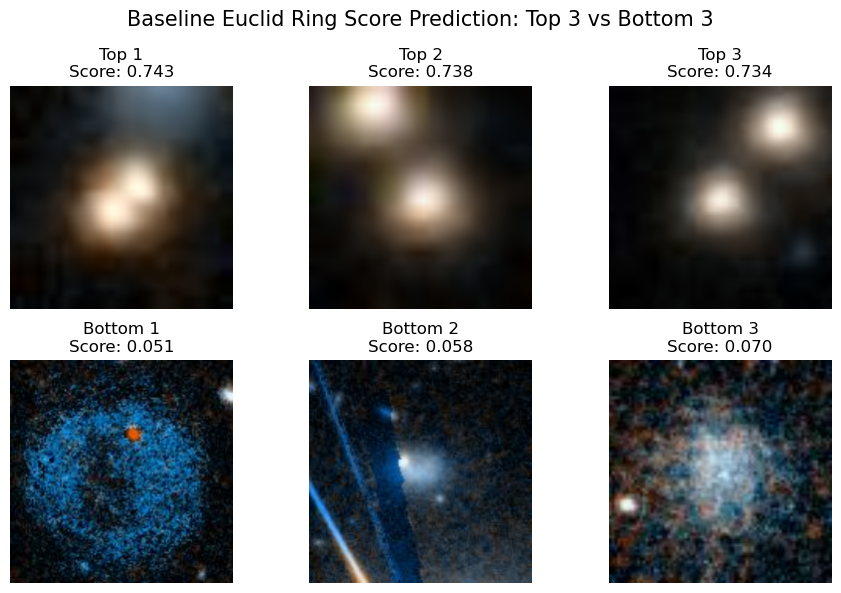

In [ ]:
df = pd.DataFrame({'pred_score': euclid_test_out['predictions'],
                   'index': euclid_test_out['indices']})

# select top 5 and worse
top5 = df.nlargest(4, 'pred_score')
top5 = top5[1:]
bottom5 = df.nsmallest(3, 'pred_score')

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()


# conver images from the dataset into a plottable numpy array
def to_np(img):
    # [C, H, W] -> [H, W, C]
    arr = img.permute(1, 2, 0).cpu().numpy()
    # scale back to [0, 1]
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr

# plot the top 5

for i, row in enumerate(top5.itertuples()):
    sample = euclid_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i].imshow(img_np)
    axes[i].set_title(f'Top {i+1}\nScore: {row.pred_score:.3f}')
    axes[i].axis('off')

# plot the bottom 5
for i, row in enumerate(bottom5.itertuples()):
    sample = euclid_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i + 3].imshow(img_np)
    axes[i + 3].set_title(f'Bottom {i+1}\nScore: {row.pred_score:.3f}')
    axes[i + 3].axis('off')

plt.suptitle('Baseline Euclid Ring Score Prediction: Top 3 vs Bottom 3',
              fontsize=15, y=0.98)
plt.tight_layout(h_pad = 1, w_pad = -15)
plt.savefig('euclid_baseline_topbest_worse.pdf')
plt.show()

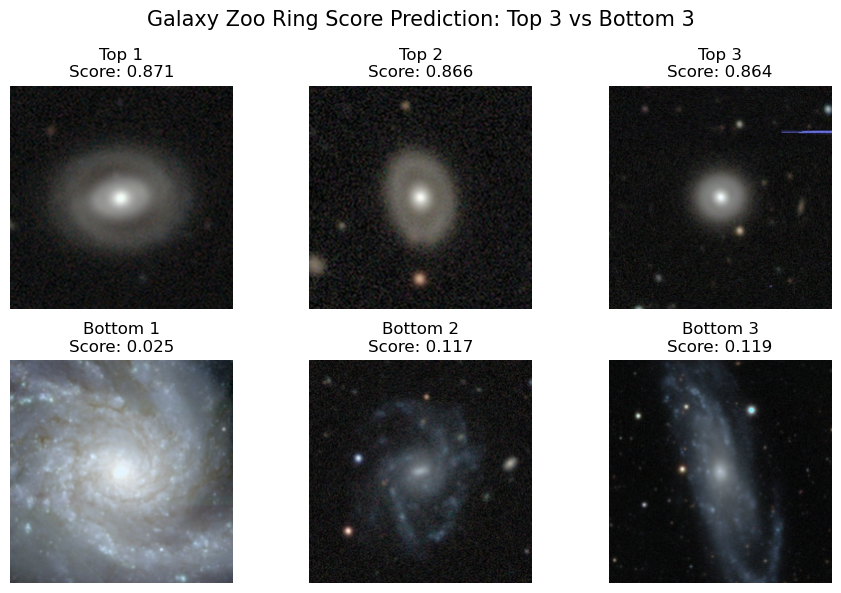

In [ ]:
# do the same for gz_rings
gz_test_out = evaluator.predict(test_loader)


df = pd.DataFrame({'pred_score': gz_test_out['predictions'],
                   'index': gz_test_out['indices']})

# select top 5 and worse
top5 = df.nlargest(4, 'pred_score')
top5 = top5[1:]
bottom5 = df.nsmallest(3, 'pred_score')

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()


# conver images from the dataset into a plottable numpy array
def to_np(img):
    # [C, H, W] -> [H, W, C]
    arr = img.permute(1, 2, 0).cpu().numpy()
    # scale back to [0, 1]
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    return arr

# plot the top 5

for i, row in enumerate(top5.itertuples()):
    sample = ring_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i].imshow(img_np)
    axes[i].set_title(f'Top {i+1}\nScore: {row.pred_score:.3f}')
    axes[i].axis('off')

# plot the bottom 5
for i, row in enumerate(bottom5.itertuples()):
    sample = ring_sets['test'][int(row.index)]
    img_np = to_np(sample['image'])
    axes[i + 3].imshow(img_np)
    axes[i + 3].set_title(f'Bottom {i+1}\nScore: {row.pred_score:.3f}')
    axes[i + 3].axis('off')

plt.suptitle('Galaxy Zoo Ring Score Prediction: Top 3 vs Bottom 3',
              fontsize=15, y=0.98)
plt.tight_layout(h_pad = 1, w_pad = -15)
plt.savefig('baseline_topbest_worse.pdf')
plt.show()